# 04 - Cross-model Evaluation

Side-by-side comparison of all three models on the shared test set.  
Metrics: macro F1, per-class F1, confusion matrices.

**Depends on:**
- `data/processed/test.csv` (produced by `00_preprocessing.ipynb`)
- Saved prediction CSVs from notebooks 01, 02, and 03

> Each model notebook saves predictions to `data/preds/` as a CSV with columns `[topic_label, y_pred]` named `nb_preds.csv`, `svm_preds.csv`, `roberta_preds.csv`. Load those here.

## 1. Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix)

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
REPO_ROOT    = os.path.dirname(NOTEBOOK_DIR)
DATA_DIR     = os.path.join(REPO_ROOT, 'data')
RESULTS_DIR  = os.path.join(REPO_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

## 2. Load predictions from each model

> Replace this section with real prediction files once models are trained.

In [2]:
test_df       = pd.read_csv(os.path.join(DATA_DIR, 'processed', 'test.csv'))
TOPIC_NAMES   = sorted(test_df['topic'].unique())  # alphabetical = label order
N_CLASSES     = len(TOPIC_NAMES)

nb_preds      = pd.read_csv(os.path.join(DATA_DIR, 'preds', 'nb_preds.csv'))
svm_preds     = pd.read_csv(os.path.join(DATA_DIR, 'preds', 'svm_preds.csv'))
roberta_preds = pd.read_csv(os.path.join(DATA_DIR, 'preds', 'roberta_preds.csv'))

models = {
    'Naive Bayes': nb_preds,
    'LinearSVC':   svm_preds,
    'RoBERTa':     roberta_preds,
}

## 3. Summary metrics table

In [3]:
rows = []
for name, preds in models.items():
    y_true = preds['topic_label']
    y_pred  = preds['y_pred']
    rows.append({
        'Model':    name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Macro F1': round(f1_score(y_true, y_pred, average='macro'), 4),
    })
summary = pd.DataFrame(rows).set_index('Model')
display(summary)

,Accuracy,Macro F1
Model,,
Naive Bayes,0.7356,0.5318
LinearSVC,0.9048,0.8854
RoBERTa,0.9225,0.9180


## 4. Per-class F1 comparison

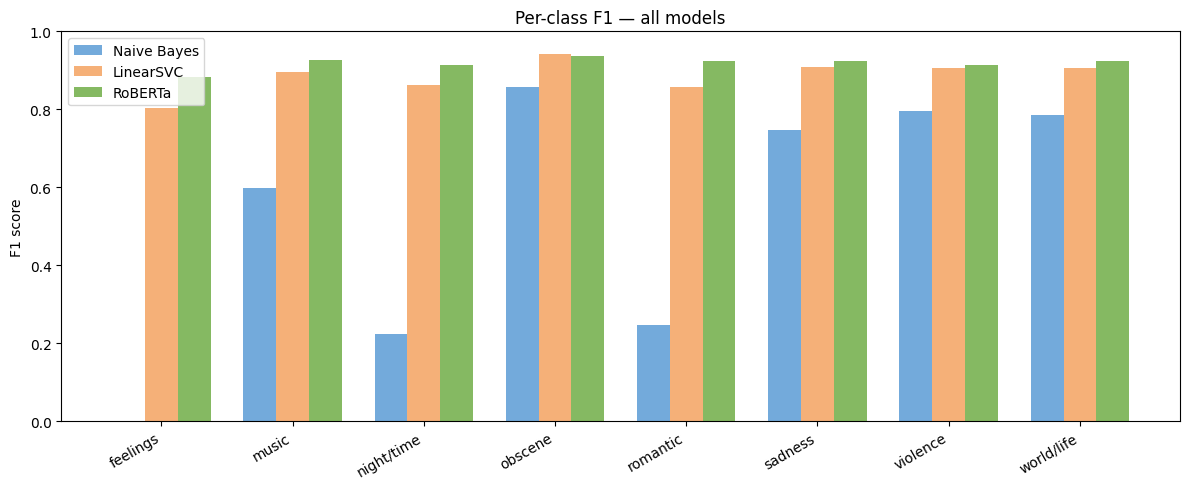

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
x      = np.arange(N_CLASSES)
width  = 0.25
palette = ['#5b9bd5', '#f4a261', '#70ad47']

for (name, preds), offset, color in zip(
        models.items(),
        [-width, 0, width],
        palette):
    f1s = f1_score(preds['topic_label'], preds['y_pred'], average=None,
                   labels=list(range(N_CLASSES)))
    ax.bar(x + offset, f1s, width, label=name, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(TOPIC_NAMES, rotation=30, ha='right')
ax.set_ylabel('F1 score')
ax.set_ylim(0, 1)
ax.set_title('Per-class F1 for all models')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'per_class_f1_comparison.png'), dpi=120)
plt.show()

## 5. Macro F1 bar chart

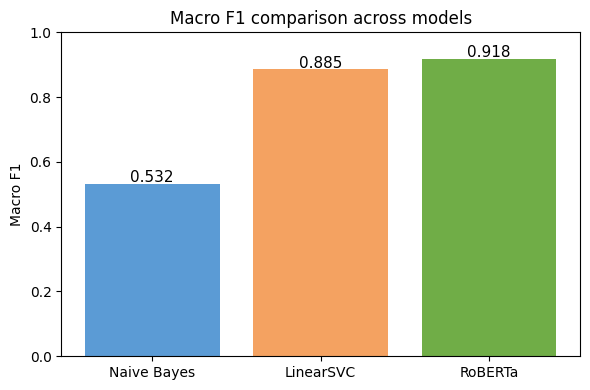

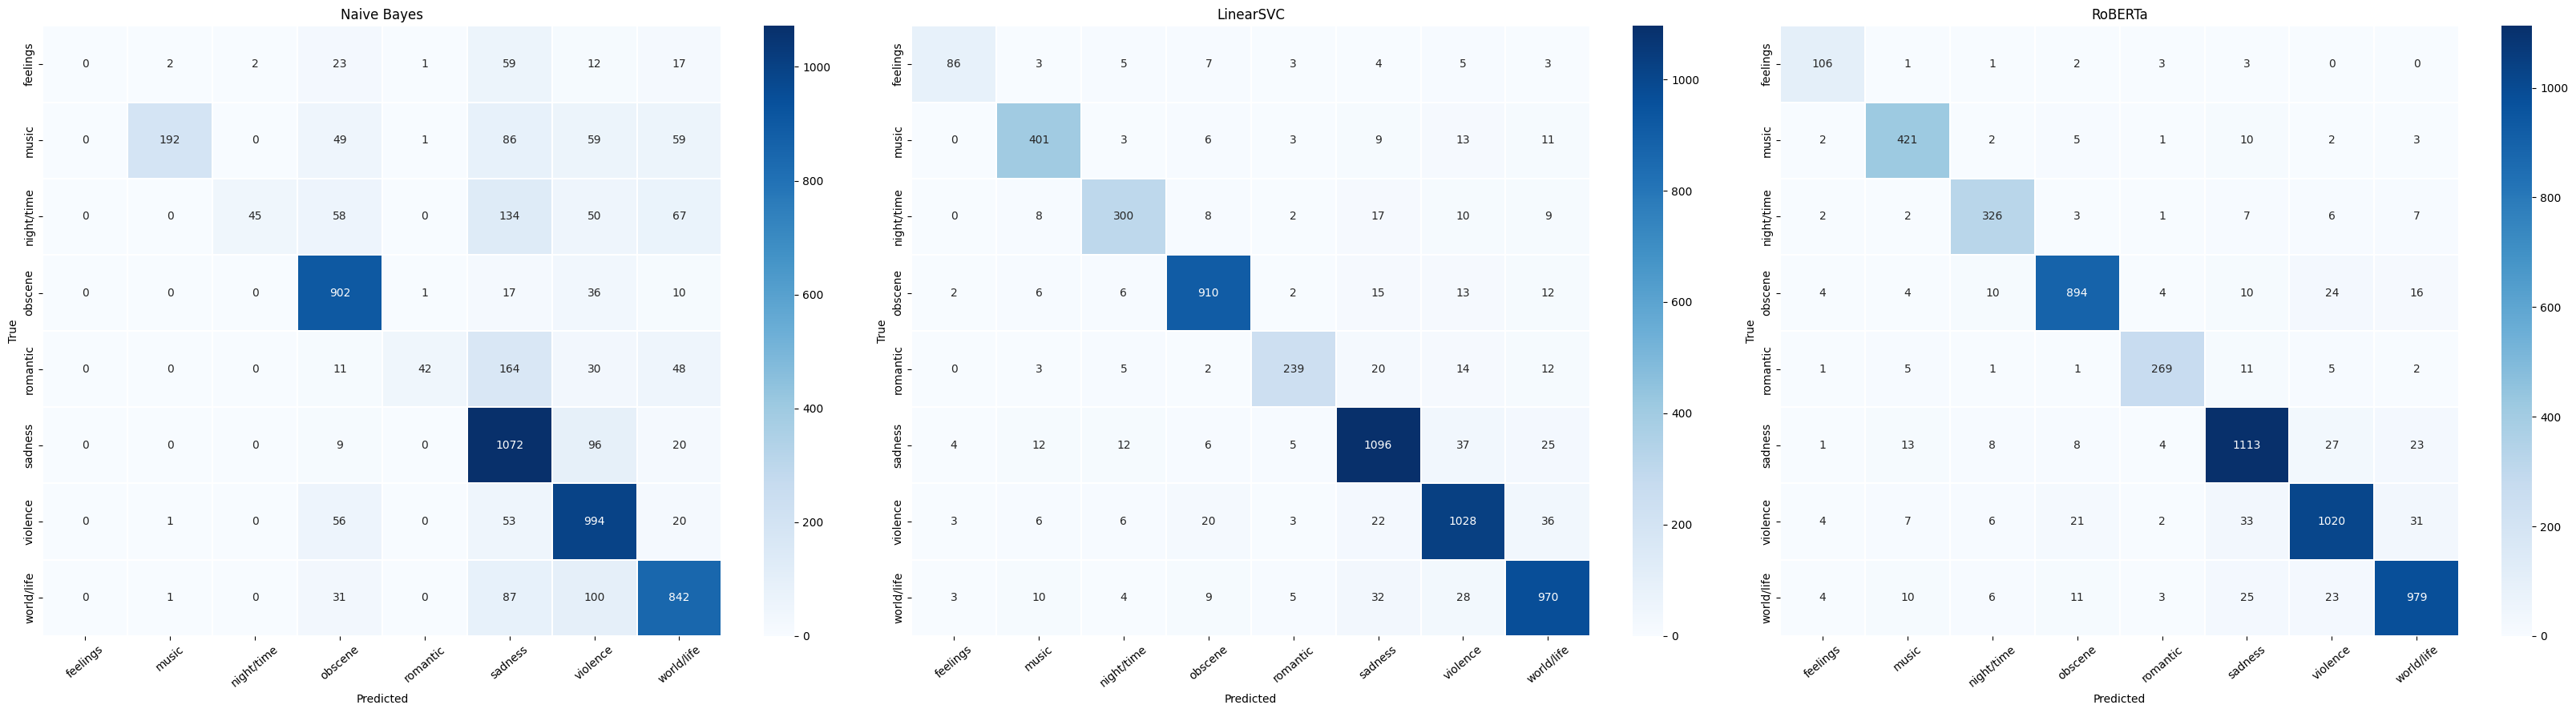

In [5]:
model_names = list(models.keys())
macro_f1s   = [f1_score(p['topic_label'], p['y_pred'], average='macro')
              for p in models.values()]
palette     = ['#5b9bd5', '#f4a261', '#70ad47']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(model_names, macro_f1s, color=palette)
for bar, v in zip(bars, macro_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
            f'{v:.3f}', ha='center', fontsize=11)
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1)
ax.set_title('Macro F1 comparison across models')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'macro_f1_comparison.png'), dpi=120)
plt.show()

# Combined confusion matrices (1×3 grid)
fig, axes = plt.subplots(1, len(models), figsize=(11 * len(models), 9))
for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(preds['topic_label'], preds['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=TOPIC_NAMES, yticklabels=TOPIC_NAMES,
                cmap='Blues', linewidths=0.3, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrices_all_models.png'), dpi=120)
plt.show()

## 6. Discussion

> Fill in after all models are trained.

- Which model achieved the highest macro F1? By how much?
- Which topics were easiest / hardest to classify, and does that match intuition?
- Did RoBERTa substantially improve over the TF-IDF baselines?
- Were any topic pairs consistently confused across all models?
- What does performance on this task say about lexical signal in song lyrics?